In [1]:
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1c"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)
df["N_features"] = df["N_features"] = df["features"].str.extract(r"RFE_(\d+)_permute")

In [2]:
val_df = df[df.dataset == "val"]
dmm_val_df = val_df[val_df.ref == "DMM"]
# val_df.features.fillna("None", inplace=True)
dmm_val_df.N_features = dmm_val_df.N_features.astype("int")

In [3]:
dmm_val_df.groupby(["context", "N_features"]).rmse.mean()

context          N_features
cytof_init       5             0.599726
                 10            0.527314
                 15            0.532473
                 20            0.572228
                 25            0.602548
                 30            0.708118
multimodal       5             0.531378
                 10            0.474607
                 15            0.473025
                 20            0.571025
                 25            0.672705
                 30            0.679940
proteomics       5             0.853903
                 10            0.898709
                 15            0.754614
                 20            0.829734
                 25            0.717523
                 30            0.872403
transcriptomics  5             0.768776
                 10            0.839290
                 15            0.735548
                 20            0.680485
                 25            0.723031
                 30            0.763301
Name: rmse, 

In [4]:
dmm_val_df.groupby(["context", "N_features"]).rmse.median()

context          N_features
cytof_init       5             0.573995
                 10            0.519751
                 15            0.490618
                 20            0.534355
                 25            0.561599
                 30            0.566504
multimodal       5             0.513655
                 10            0.462043
                 15            0.479698
                 20            0.543236
                 25            0.570686
                 30            0.647516
proteomics       5             0.820490
                 10            0.955733
                 15            0.737575
                 20            0.829487
                 25            0.612081
                 30            0.870449
transcriptomics  5             0.760030
                 10            0.871668
                 15            0.693370
                 20            0.682895
                 25            0.680360
                 30            0.708891
Name: rmse, 

# Number of features

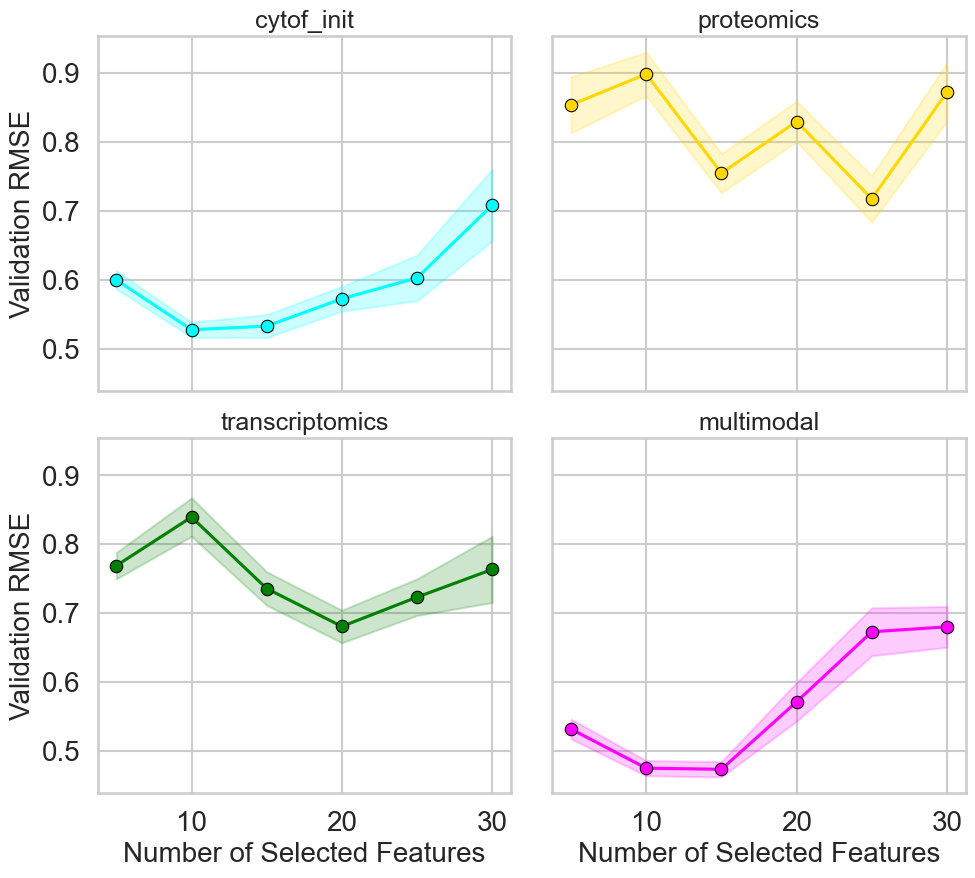

In [16]:
import matplotlib.pyplot as plt
# Set a modern style
sns.set_theme(style="whitegrid", context="talk")

palette = {
    "cytof_init": "cyan",
    "proteomics": "gold",
    "transcriptomics": "green",
    "multimodal": "coral",
}

g = sns.FacetGrid(
    dmm_val_df,
    col="context",
    col_order=palette.keys(),
    col_wrap=2,
    sharey=True,
    despine=False,
    height=5,
)

g.map_dataframe(
    sns.lineplot,
    x="N_features",
    y="rmse",
    marker='o',
    hue="context",
    palette=palette,
    mec="black",
    errorbar="se"
)

# Add axis labels and titles
g.set_axis_labels("Number of Selected Features", "Validation RMSE", fontsize=20)
g.set_titles(col_template="{col_name}", fontsize=20)

# Enlarge tick labels
for ax in g.axes.flatten():
    ax.tick_params(axis='both', which='major', labelsize=20)


# Adjust layout
plt.subplots_adjust(top=0.85, wspace=0.10)
plt.savefig("feature_selection.svg")
plt.show()

In [6]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric, context_metric="context"):
    for context in df[context_metric].unique():
        context_data = df[df[context_metric] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context/Group: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

In [21]:
kruskal_wallis_groups(
    dmm_val_df[dmm_val_df.N_features <= 15],
    "rmse",
    "N_features",
    "context"
)

Context/Group: proteomics - Kruskal-Wallis H-test: H-statistic=10.38, p-value=0.0056, significant? True
Context/Group: transcriptomics - Kruskal-Wallis H-test: H-statistic=8.86, p-value=0.0119, significant? True
Context/Group: multimodal - Kruskal-Wallis H-test: H-statistic=9.39, p-value=0.0092, significant? True
Context/Group: cytof_init - Kruskal-Wallis H-test: H-statistic=21.42, p-value=0.0000, significant? True


Not significant for cytof_init or transcriptomics. multimodal only gets worse. proteomics is the only context where there seems to be an honest and significant benefit in using more features - is it just that feature selection cannot find relevant features at all and this increases the chances of finding remotely useful ones?